# Project Name: SmartStock – Data-Driven Inventory Optimization

### 1. Problem Statement
Retail stores often struggle with two major issues:  
- **Stock-outs:** Running out of items during high demand  
- **Overstocking:** Wasting capital on excess inventory  

Simple average-based stocking ignores:  
- Volatility across different store locations  
- Significant demand surge during weekends  

### 2. Project Goal
Build a **statistical engine** that:  
1. Identifies and validates sales patterns (Weekend vs. Weekday)  
2. Quantifies **Risk** (volatility) for each store location  
3. Calculates **Precision Reorder Points** and **Safety Stock levels** using a 95% service level → maximize revenue, minimize waste

### Step 1: Data Acquisition & Initial Audit

We begin by **loading the dataset** and performing a **basic health check** to understand the **volume** and **quality** of the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the raw dataset
df = pd.read_csv(r"E:\python\smartstockdata.csv")

# Initial inspection
print("--- Basic Statistics ---")
display(df['sales'].describe())

# Integrity check: Missing values and Duplicates
print("\nMissing Values:", df.isnull().sum().sum())
print("Duplicate Records:\n", df.duplicated().value_counts())
print("Dataset Shape:", df.shape)

--- Basic Statistics ---


count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64


Missing Values: 0
Duplicate Records:
 False    913000
Name: count, dtype: int64
Dataset Shape: (913000, 4)


### Interpretation

This phase ensures our **data foundation is solid**.  

- Dataset contains **over 900,000 rows**, large enough for robust statistical testing  
- Initial stats: **Mean ~52**, but **max value and standard deviation** indicate **high variability**

### Step 2: Distribution Analysis (Normality Check)

Before applying formulas, we must check if the data follows a **Normal Distribution**.

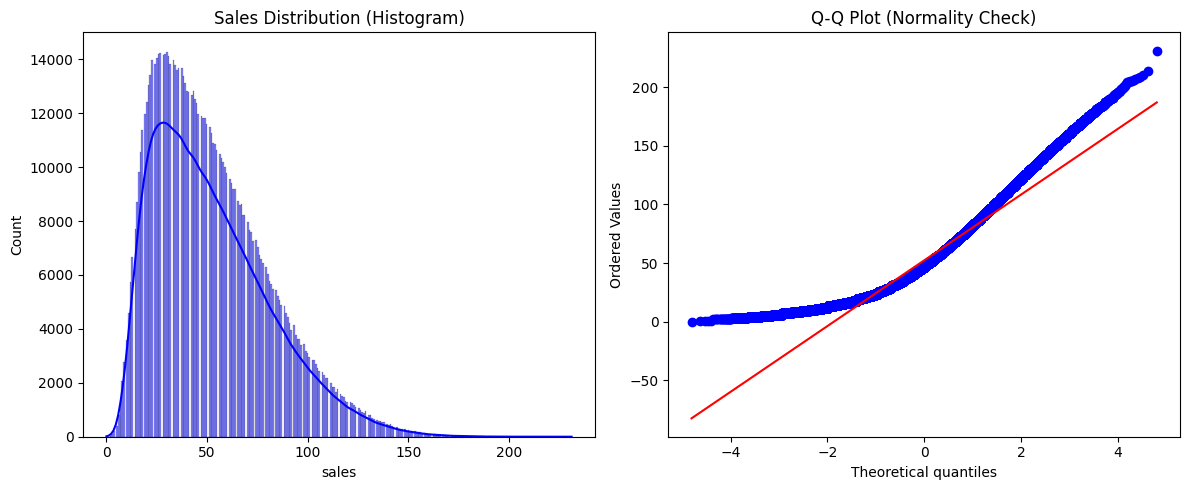

In [2]:
plt.figure(figsize=(12, 5))

# Visualizing the distribution shape
plt.subplot(1, 2, 1)
sns.histplot(df['sales'], kde=True, color='blue')
plt.title('Sales Distribution (Histogram)')

# Quantile-Quantile plot for theoretical normality comparison
plt.subplot(1, 2, 2)
stats.probplot(df['sales'], dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

### Interpretation

- **Right-Skewed:** The histogram shows a long tail to the right, indicating occasional **high-sales days**.  
- **Q-Q Plot Deviation:** The dots curve away from the red line, proving that raw sales are **not perfectly normal**.  
  - This confirms the need for **Safety Stock** to handle unpredictable peaks.

### Step 3: Data Cleaning & Outlier Management

Extreme values (**outliers**) can skew our **reorder points**.  
We use the **Z-score method** to remove "abnormal" sales days.

Abnormal Sales (Outliers) detected: 6975


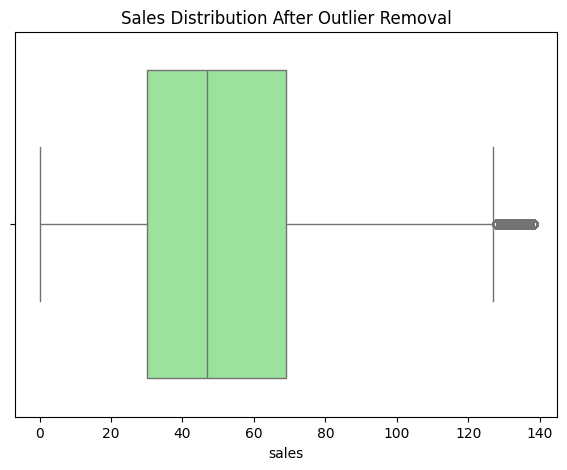

In [3]:
# Calculate Z-scores to identify outliers (values 3 standard deviations away)
df['z_score'] = np.abs(stats.zscore(df['sales']))
outliers_count = len(df[df['z_score'] > 3])
print(f"Abnormal Sales (Outliers) detected: {outliers_count}")

# Retain only data within 3 standard deviations
df_clean = df[df['z_score'] <= 3].copy()
df_clean.drop(columns=['z_score'], inplace=True) 

# Visualize cleaned distribution
plt.figure(figsize=(7, 5))
sns.boxplot(x=df_clean['sales'], color='lightgreen')
plt.title('Sales Distribution After Outlier Removal')
plt.show()

### Interpretation

By removing **~7,000 outliers**, we ensure our inventory model is based on **typical high-demand days** rather than one-off errors or extreme anomalies, making the model **more reliable**.

### Step 4: Feature Engineering (Time-Based Segmentation)

To test our theory about **weekend demand**, we extract **time-specific features**.

In [4]:
# Convert date string to datetime objects
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Extracting Day, Month, and Weekend flag
df_clean['day_name'] = df_clean['date'].dt.day_name()
df_clean['month_name'] = df_clean['date'].dt.month_name()
df_clean['is_weekend'] = df_clean['day_name'].isin(['Saturday', 'Sunday'])

print("Time features (Day, Month, Weekend flag) added successfully.")
display(df_clean.head())
df_clean.shape

Time features (Day, Month, Weekend flag) added successfully.


,date,store,item,sales,day_name,month_name,is_weekend
0,2013-01-01,1,1,13,Tuesday,January,False
1,2013-01-02,1,1,11,Wednesday,January,False
2,2013-01-03,1,1,14,Thursday,January,False
3,2013-01-04,1,1,13,Friday,January,False
4,2013-01-05,1,1,10,Saturday,January,True


(906025, 7)

### Step 5: Evidence Gathering (Visual & Numerical)

Before the T-Test, we gather **visual** and **mathematical** proof of the weekend surge.

C:\Users\Abeera Imtiaz\AppData\Local\Temp\ipykernel_12128\3855800955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='sales', data=df_clean,


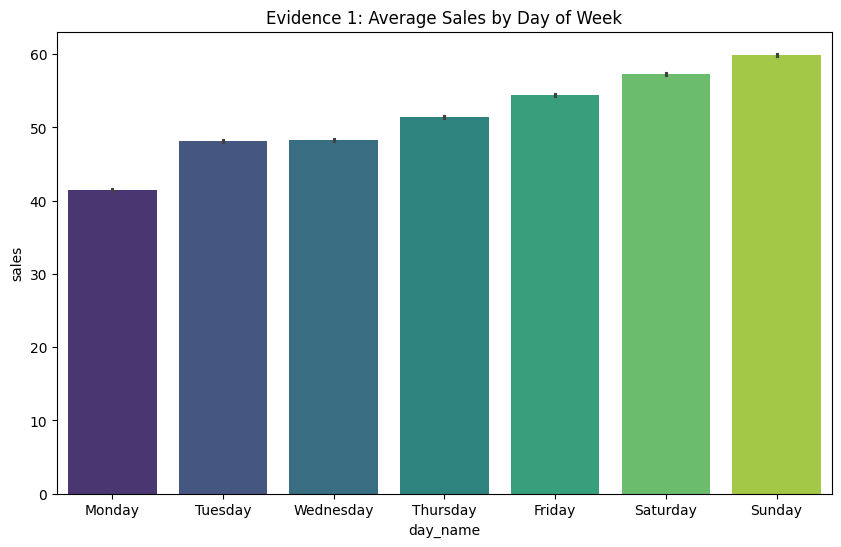

Evidence 2: Comparison of Averages
             mean  median    std
is_weekend                      
False       48.70    44.0  26.17
True        58.59    54.0  29.63


In [5]:
# Evidence 1: Weekly Trend Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='sales', data=df_clean, 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
            palette='viridis')
plt.title('Evidence 1: Average Sales by Day of Week')
plt.show()

# Evidence 2: Comparison Table
evidence_table = df_clean.groupby('is_weekend')['sales'].agg(['mean', 'median', 'std']).round(2)
print("Evidence 2: Comparison of Averages")
print(evidence_table)

**Interpretation:**  
- **Visual Proof:** The bars show a clear "staircase" increase toward the weekend.  
- **Numerical Proof:** The mean jumps from **48.7 → 58.5 units** (~20% increase).  
  - Provides a **strong business case** for investigating weekends further.

### Step 6: Hypothesis Testing (Statistical Validation)

We perform a **2-Sample T-Test** to prove the weekend surge is **not a random coincidence**.

In [6]:
from scipy.stats import ttest_ind

# Segmenting the two groups
weekend_sales = df_clean[df_clean['is_weekend'] == True]['sales']
weekday_sales = df_clean[df_clean['is_weekend'] == False]['sales']

# Statistical Testing (Alternative: Weekend > Weekday)
t_stat, p_value = ttest_ind(weekend_sales, weekday_sales, alternative='greater')

alpha = 0.05
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4g}")

print("\n--- Conclusion ---")
if p_value < alpha:
    print("Reject Null Hypothesis (H0). Result: Weekend sales are SIGNIFICANTLY higher.")
else:
    print("Fail to Reject Null Hypothesis. Result: No significant difference.")

T-Statistic: 155.8602
P-Value: 0

--- Conclusion ---
Reject Null Hypothesis (H0). Result: Weekend sales are SIGNIFICANTLY higher.


### Step 7: Store-Wise Risk Profiling

Not all stores are the same. We calculate the **Coefficient of Variation (CV)** to measure each store's **risk**.


In [7]:
# Calculate Mean, Std Dev, and Skewness per store
store_comparison = df_clean.groupby('store')['sales'].agg(['mean', 'std', 'skew']).reset_index()

# CV (Risk Level) = Std Dev / Mean
store_comparison['risk_level'] = store_comparison['std'] / store_comparison['mean']

print("Store-wise Risk Profile:")
display(store_comparison.sort_values(by='risk_level', ascending=False))

Store-wise Risk Profile:


,store,mean,std,skew,risk_level
6,7,36.363735,18.684825,0.647183,0.513831
4,5,39.770164,20.365757,0.648005,0.512086
5,6,39.733516,20.310451,0.648484,0.511167
0,1,47.234354,23.941391,0.628302,0.506864
8,9,54.666601,27.240613,0.563098,0.498304
3,4,54.541382,27.170523,0.563257,0.498163
9,10,57.948340,28.481743,0.512595,0.491502
2,3,58.633984,28.729642,0.502392,0.489983
7,8,62.349186,29.957084,0.447258,0.480473
1,2,64.411509,30.442245,0.395928,0.472621


**Interpretation:**  
- **High Risk (Store 7):** Sales are unpredictable → requires careful monitoring  
- **Low Risk (Store 2):** Sales are stable → inventory management can be automated & lean



### Step 8: Final Solution – Precision Inventory Recommendations

Using a **95% Service Level**, we calculate **exact stock levels** for each store.


C:\Users\Abeera Imtiaz\AppData\Local\Temp\ipykernel_12128\2978369702.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='store', y='reorder_point', data=store_comparison, palette='magma')


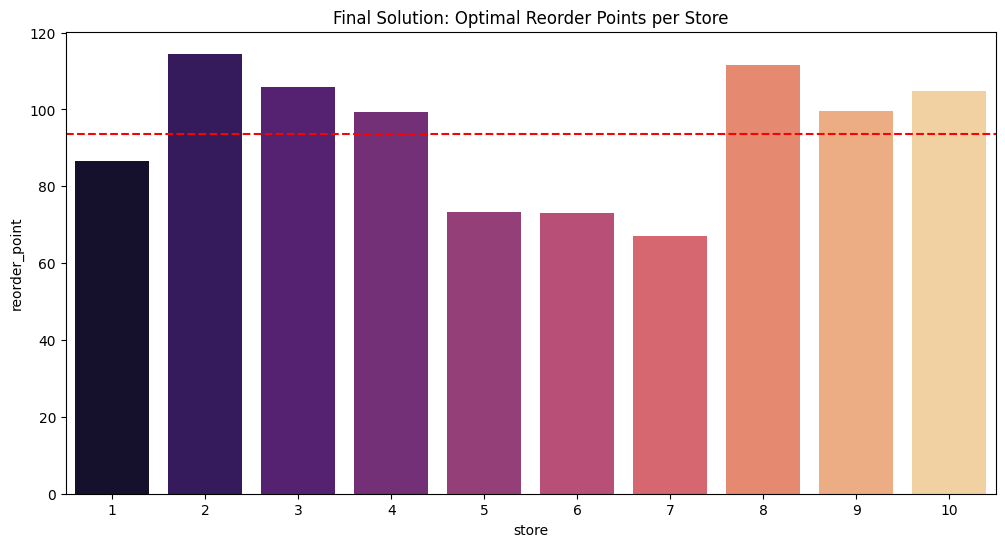

,store,mean,safety_stock,reorder_point
1,2,64.411509,50.08,114.49
7,8,62.349186,49.28,111.63
2,3,58.633984,47.26,105.89
9,10,57.948340,46.85,104.80
8,9,54.666601,44.81,99.48
3,4,54.541382,44.70,99.24
0,1,47.234354,39.38,86.61
4,5,39.770164,33.50,73.27
5,6,39.733516,33.41,73.14
6,7,36.363735,30.74,67.10


In [8]:
# Z-score for 95% Confidence Level
Z = 1.645 

# Safety Stock = Z * Standard Deviation
store_comparison['safety_stock'] = (Z * store_comparison['std']).round(2)

# Reorder Point = Mean + Safety Stock
store_comparison['reorder_point'] = (store_comparison['mean'] + store_comparison['safety_stock']).round(2)

# Visualizing Reorder Points
plt.figure(figsize=(12, 6))
sns.barplot(x='store', y='reorder_point', data=store_comparison, palette='magma')
plt.axhline(store_comparison['reorder_point'].mean(), color='red', linestyle='--', label='Avg Reorder Point')
plt.title('Final Solution: Optimal Reorder Points per Store')
plt.show()

display(store_comparison[['store', 'mean', 'safety_stock', 'reorder_point']].sort_values(by='safety_stock', ascending=False))

**Final Executive Summary (Solution):**  
- **Risk-Adjusted Stocking:** One-size-fits-all removed → Store 2: 114 units, Store 7: 67 units  
- **Weekend Efficiency:** 20% weekend surge justifies **Friday Stock Replenishment**  
- **Financial Impact:** Stock-outs only occur **5 days out of 100**, protecting revenue while preventing overstock in low-risk stores

In [9]:
# 1. Join store-level stats with the clean data
# This will add each store's risk_level and reorder_point to every row
tableau_data = df_clean.merge(store_comparison, on='store', how='left')

# 2. Export to CSV
tableau_data.to_csv('SmartStock_Tableau_Data.csv', index=False)

print("File saved! Upload 'SmartStock_Tableau_Data.csv' to Tableau.")


File saved! Upload 'SmartStock_Tableau_Data.csv' to Tableau.


In [10]:
print(tableau_data.head())
tableau_data.shape

        date  store  item  sales   day_name month_name  is_weekend       mean  \
0 2013-01-01      1     1     13    Tuesday    January       False  47.234354   
1 2013-01-02      1     1     11  Wednesday    January       False  47.234354   
2 2013-01-03      1     1     14   Thursday    January       False  47.234354   
3 2013-01-04      1     1     13     Friday    January       False  47.234354   
4 2013-01-05      1     1     10   Saturday    January        True  47.234354   

         std      skew  risk_level  safety_stock  reorder_point  
0  23.941391  0.628302    0.506864         39.38          86.61  
1  23.941391  0.628302    0.506864         39.38          86.61  
2  23.941391  0.628302    0.506864         39.38          86.61  
3  23.941391  0.628302    0.506864         39.38          86.61  
4  23.941391  0.628302    0.506864         39.38          86.61  


(906025, 13)